In [3]:
import os
import re
import glob
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict


# --- Configuration ---
ROOT = os.path.expanduser("outputs")
PATTERN = os.path.join(ROOT, "**", "*.bin")
FILENAME_RE = re.compile(r"f\[(?P<f>[\d.]+)MHz\]_a\[(?P<a>[\d.]+)V\]")


def parse_freq_amp(path):
    """Extract frequency (MHz) and amplitude (V) from filename."""
    m = FILENAME_RE.search(os.path.basename(path))
    if not m:
        return None
    return float(m.group("f")), float(m.group("a"))


def peak_to_peak(path, dtype=np.float64):
    trace = np.fromfile(path, dtype=dtype)
    if trace.size == 0:
        return np.nan
    return np.ptp(trace)



def rms_ac(path, dtype=np.float64):
    x = np.fromfile(path, dtype=dtype)
    if x.size == 0:
        return np.nan
    x = x - np.mean(x)
    return np.sqrt(np.mean(x*x))



def build_heatmap(records):
    freqs = sorted({f for f, _, _ in records})
    amps  = sorted({a for _, a, _ in records})

    fi = {f: i for i, f in enumerate(freqs)}
    ai = {a: i for i, a in enumerate(amps)}

    Z = np.full((len(amps), len(freqs)), np.nan)

    for f, a, v in records:
        Z[ai[a], fi[f]] = v

    return freqs, amps, Z


def plot_folder(folder_name, records):
    freqs, amps, Z = build_heatmap(records)

    extent = [min(freqs), max(freqs), min(amps), max(amps)]

    plt.figure()
    im = plt.imshow(
        Z,
        origin="lower",
        aspect="auto",
        extent=extent,
        interpolation="nearest",
    )

    plt.xlabel("Frequency (MHz)")
    plt.ylabel("Amplitude (V)")
    plt.title(folder_name)   # Title = folder name
    plt.colorbar(im, label="RMS")
    plt.tight_layout()
    plt.show()



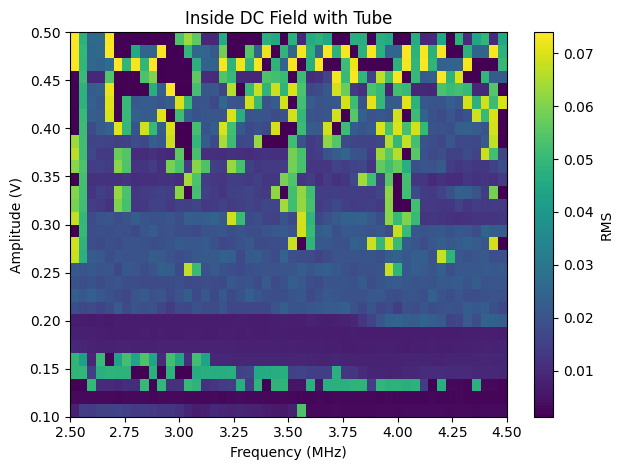

In [5]:

files = glob.glob(PATTERN, recursive=True)

# Group data by parent folder
grouped = defaultdict(list)

for path in files:
    parsed = parse_freq_amp(path)
    if parsed is None:
        continue

    freq, amp = parsed
    value = rms_ac(path)

    folder_name = os.path.basename(os.path.dirname(path))
    grouped[folder_name].append((freq, amp, value))


# Plot one heatmap per folder
for folder_name, records in sorted(grouped.items()):
    if records:
        plot_folder(folder_name, records)